<a href="https://colab.research.google.com/github/Yaaxek/IA-aumentada-prevision-de-atrasos-de-vuelos/blob/main/Previsi%C3%B3n_de_atrasos_de_vuelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Optimizacion aeroportuaria**

##Datos iniciales

In [67]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick
import matplotlib.pyplot as plt

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
datos=pd.read_csv('/content/drive/MyDrive/Machine Learning/flights.csv')
datos.shape

(71175, 11)

In [70]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


##Exploración y Resumen de Datos

In [71]:
#Todos los tiempos estan en minutos y segundos por ejemplo el delay del primer caso
print(f'El vuelo 26 de la aerolinea MM se retraso 70 min {.205981*60:.0f} segundos')

#En el caso del arrival y departure esta en hora y minuto, por ejemplo el primer caso
print(f'El vuelo 26 de la aerolinea MM salio a las 8:{.885071*60:.0f} y llego a las 10:{.885071	*60:.0f}')

El vuelo 26 de la aerolinea MM se retraso 70 min 12 segundos
El vuelo 26 de la aerolinea MM salio a las 8:53 y llego a las 10:53


In [72]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [73]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [74]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


##Exploracion de los datos con graficas

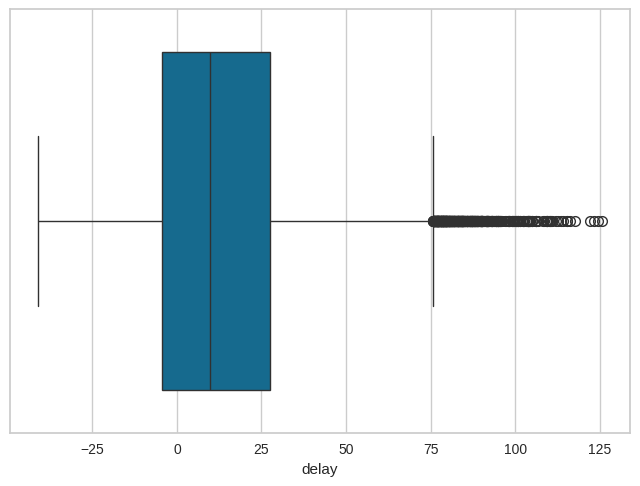

In [75]:
sns.boxplot(data=datos.delay, orient='h');

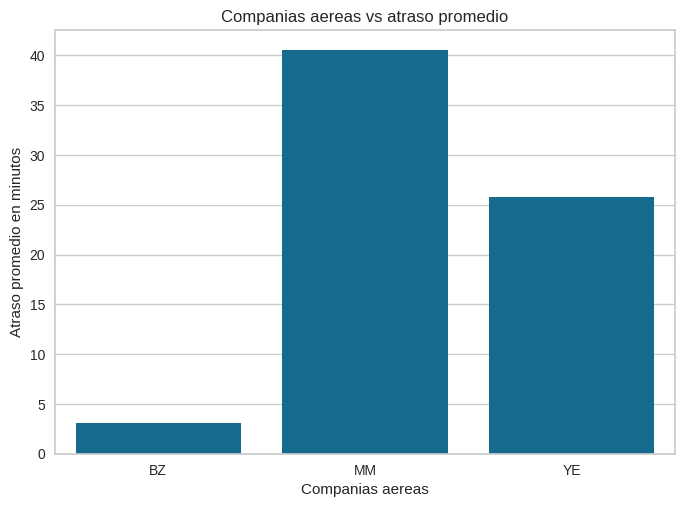

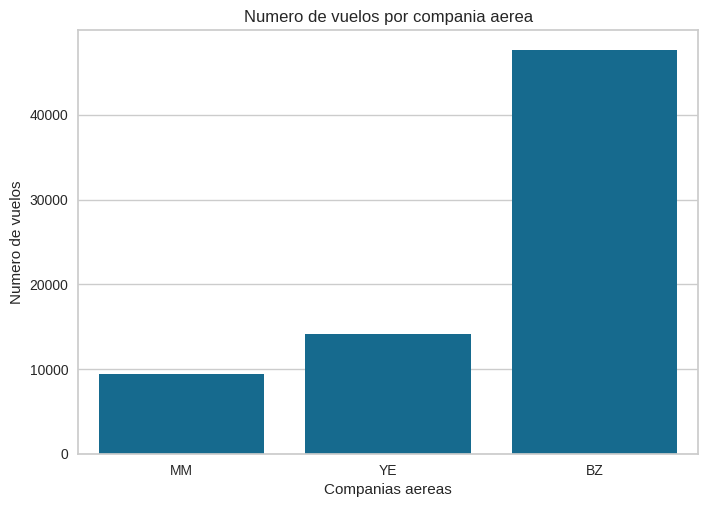

In [76]:
avg_delay=datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline',y='delay',data=avg_delay)
plt.title('Companias aereas vs atraso promedio')
plt.xlabel('Companias aereas')
plt.ylabel('Atraso promedio en minutos')
plt.show()

sns.countplot(data=datos,x='airline')
plt.title('Numero de vuelos por compania aerea')
plt.xlabel('Companias aereas')
plt.ylabel('Numero de vuelos')
plt.show()

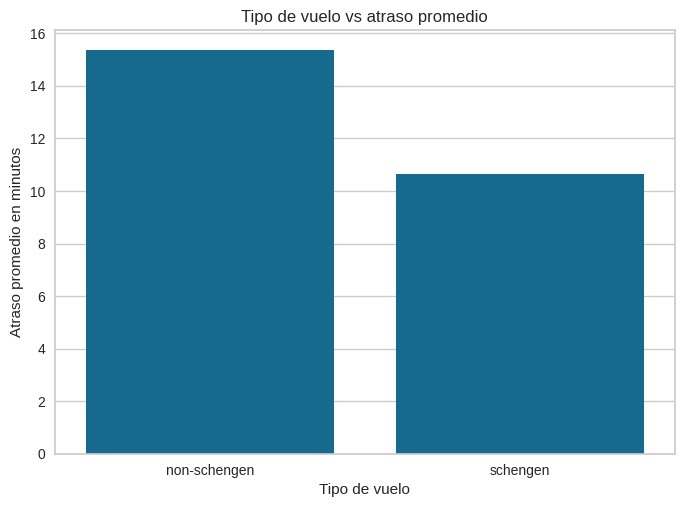

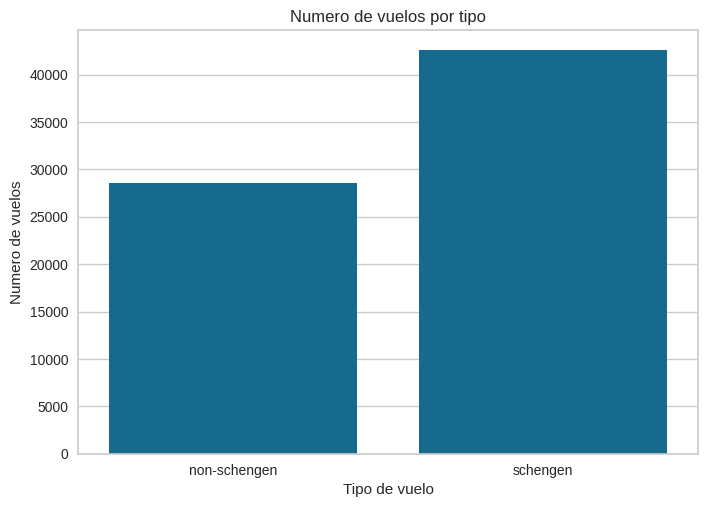

In [77]:
avg_delay=datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen',y='delay',data=avg_delay)
plt.title('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Atraso promedio en minutos')
plt.show()

sns.countplot(data=datos,x='schengen')
plt.title('Numero de vuelos por tipo')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Numero de vuelos')
plt.show()

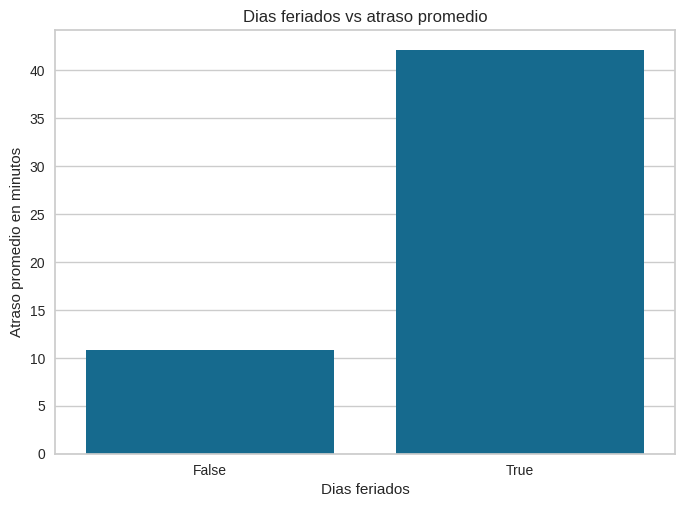

In [78]:
avg_delay=datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday',y='delay',data=avg_delay)
plt.title('Dias feriados vs atraso promedio')
plt.xlabel('Dias feriados')
plt.ylabel('Atraso promedio en minutos')
plt.show()


In [79]:
order=datos['aircraft_type'].value_counts().index
order

Index(['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175',
       'Boeing 737', 'Boeing 777'],
      dtype='object', name='aircraft_type')

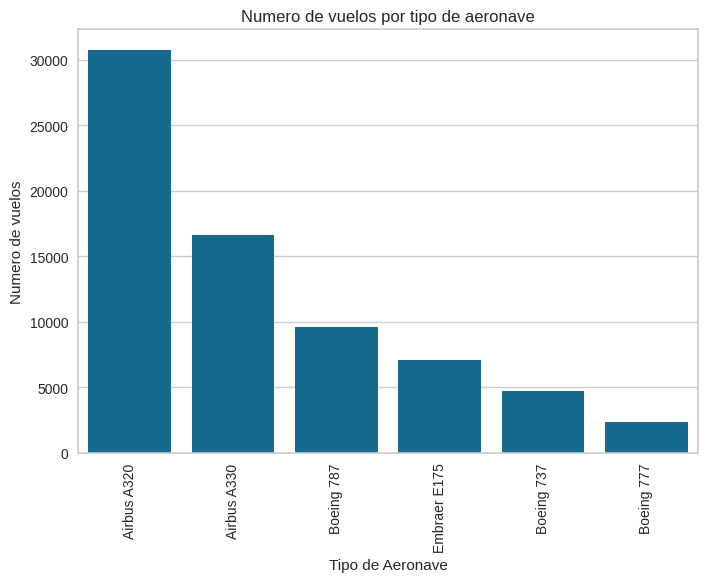

In [80]:
order=datos['aircraft_type'].value_counts().index
sns.countplot(data=datos,x='aircraft_type',order=order)
plt.title('Numero de vuelos por tipo de aeronave')
plt.xticks(rotation=90)
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Numero de vuelos')
plt.show()

[Freedman Diaconis regla de los bins]('https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule')

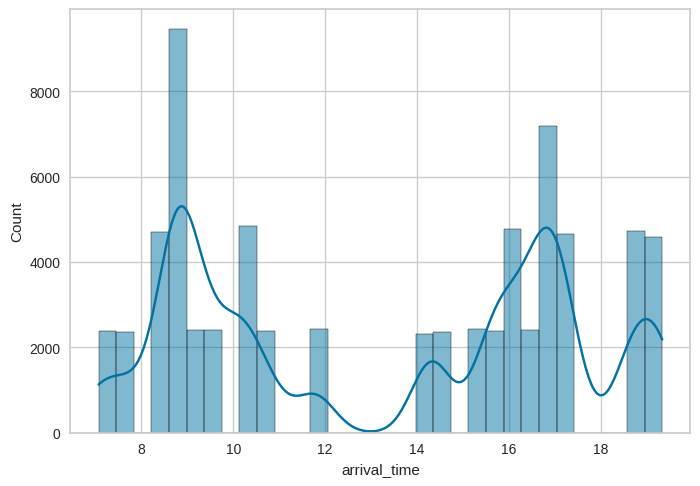

In [81]:
sns.histplot(data=datos,x='arrival_time',kde=True);

In [82]:
import numpy as np
def ancho_bin(df,columna):
  q75,q25=np.percentile(df[columna],[75,25])
  iqr=q75-q25
  ancho=2*iqr*np.power(len(df[columna]),-1/3)
  return ancho

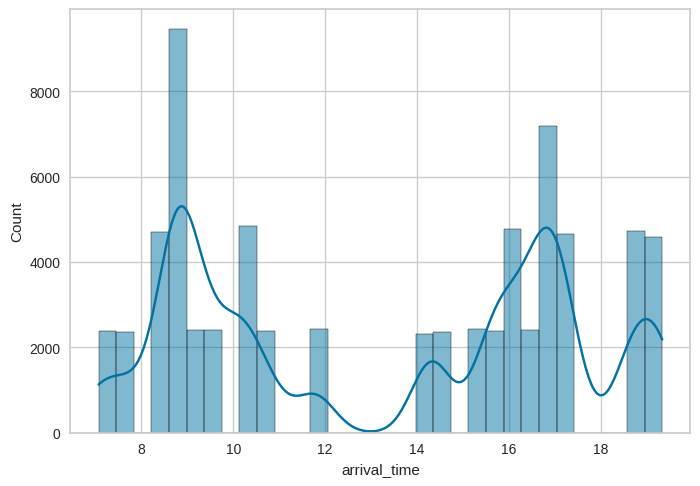

In [83]:
binwidth=ancho_bin(datos,'arrival_time')
sns.histplot(data=datos,x='arrival_time',kde=True,binwidth=binwidth);

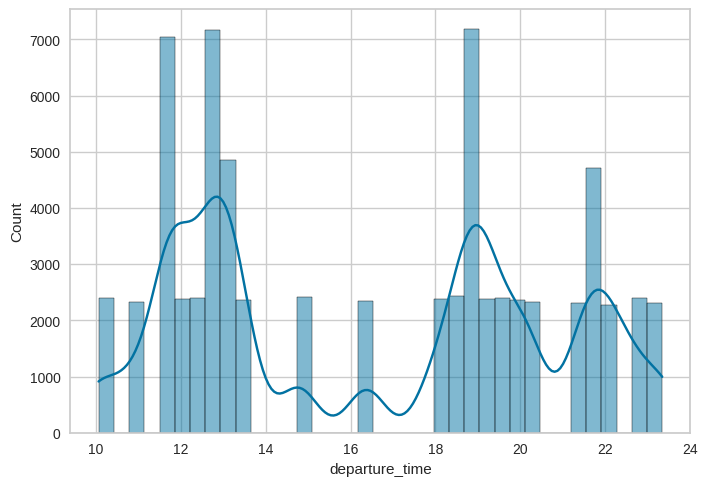

In [84]:
binwidth=ancho_bin(datos,'departure_time')
sns.histplot(data=datos,x='departure_time',kde=True,binwidth=binwidth);

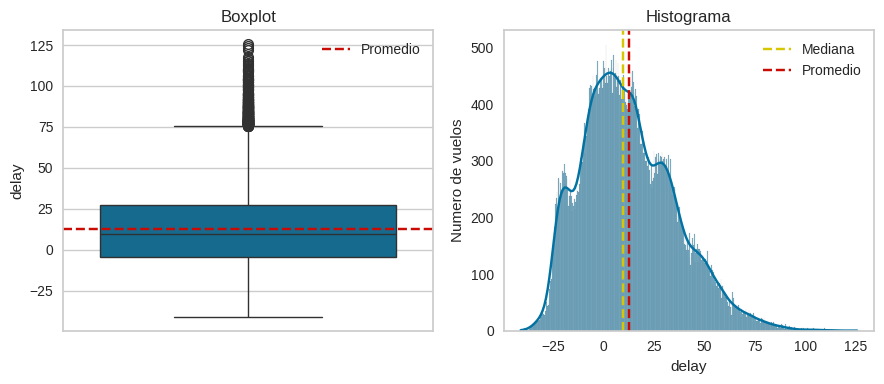

In [85]:
atraso_promedio=datos['delay'].mean()
atraso_mediana=datos['delay'].median()

fig,ax=plt.subplots(1,2,figsize=(9,4))
sns.boxplot(data=datos,y='delay',ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio,color='r',linestyle='--',label='Promedio')
ax[0].legend()


binwidht=ancho_bin(datos,'delay')
sns.histplot(data=datos,x='delay',ax=ax[1],kde=True, binwidth=binwidth)
plt.ylabel('Numero de vuelos')
ax[1].set_title('Histograma')
plt.grid(False)
ax[1].axvline(x=atraso_mediana,color='y',linestyle='--',label='Mediana')
ax[1].axvline(x=atraso_promedio,color='r',linestyle='--',label='Promedio')
ax[1].legend()

plt.tight_layout()

plt.show()


In [86]:
datos.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [87]:
datos['date']=datos['year'].astype(str)+'-'+(datos['day']+1).astype(str)
datos['date']=pd.to_datetime(datos['date'],format='%Y-%j')
datos.tail(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648,2022-12-31


In [88]:
datos['is_weekend']=datos['date'].dt.weekday.isin([5,6])
datos['day_name']=datos['date'].dt.day_name()
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
18442,14,BZ,Airbus A330,schengen,ZQO,7.708301,11.708301,134,2013,False,-6.812317,2013-05-15,False,Wednesday
62670,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,163,2021,False,34.053725,2021-06-13,True,Sunday
29682,11,BZ,Airbus A320,non-schengen,EMM,10.177197,13.177197,153,2015,False,7.697409,2015-06-03,False,Wednesday
11436,6,YE,Boeing 787,schengen,AUZ,17.033688,19.033688,32,2012,False,12.771711,2012-02-02,False,Thursday
21505,22,YE,Airbus A320,non-schengen,MWL,8.794147,11.794147,338,2013,False,8.380377,2013-12-05,False,Thursday


In [89]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

In [90]:
import warnings
warnings.filterwarnings('ignore')

In [91]:
datos['schengen']=datos['schengen'].replace({'non-schengen':0,'schengen':1})
datos['is_holiday']=datos['is_holiday'].replace({False:0,True:1})
datos['is_weekend']=datos['is_weekend'].replace({False:0,True:1})
datos.sample(3)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
45004,12,YE,Airbus A330,1,TZF,17.313731,21.313731,80,2018,0,17.562039,2018-03-22,0,Thursday
8614,22,YE,Airbus A320,0,MWL,8.794147,11.794147,209,2011,0,36.831951,2011-07-29,0,Friday
11700,20,YE,Boeing 787,1,MWL,16.909690,18.909690,50,2012,0,22.941713,2012-02-20,0,Monday


In [92]:
categoricas=['airline','aircraft_type','origin','day_name']
datos_codificados=pd.get_dummies(data=datos,columns=categoricas,dtype=int)
datos_codificados.sample(5)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
18283,29,1,8.591208,11.591208,123,2013,0,-5.852560,2013-05-04,1,...,0,0,1,0,0,1,0,0,0,0
26536,13,0,10.172731,13.172731,309,2014,0,-22.570476,2014-11-06,0,...,1,0,0,0,0,0,0,1,0,0
25847,16,0,17.041281,20.041281,263,2014,0,62.467432,2014-09-21,1,...,0,0,0,0,0,0,1,0,0,0
33263,24,1,9.668655,12.668655,27,2016,0,33.072720,2016-01-28,0,...,0,0,0,0,0,0,0,1,0,0
47917,27,1,14.376052,16.376052,274,2018,0,-3.041887,2018-10-02,0,...,0,0,0,0,0,0,0,0,1,0


In [93]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

In [94]:
categoricas=['airline','aircraft_type','origin','day_name']
one=make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'),categoricas),remainder='passthrough'
)
datos=one.fit_transform(datos)
datos=pd.DataFrame(datos,columns=one.get_feature_names_out())
datos.sample(5)

,onehotencoder__airline_BZ,onehotencoder__airline_MM,onehotencoder__airline_YE,onehotencoder__aircraft_type_Airbus A320,onehotencoder__aircraft_type_Airbus A330,onehotencoder__aircraft_type_Boeing 737,onehotencoder__aircraft_type_Boeing 777,onehotencoder__aircraft_type_Boeing 787,onehotencoder__aircraft_type_Embraer E175,onehotencoder__origin_AUZ,...,remainder__flight_id,remainder__schengen,remainder__arrival_time,remainder__departure_time,remainder__day,remainder__year,remainder__is_holiday,remainder__delay,remainder__date,remainder__is_weekend
42256,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,7,1,8.564949,13.564949,262,2017,0,14.355632,2017-09-20,0
2859,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19,1,16.24522,19.24522,190,2010,0,33.1113,2010-07-10,1
17362,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,21,1,7.065594,10.065594,62,2013,0,54.888985,2013-03-04,0
22775,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,14,1,7.708301,11.708301,58,2014,0,-14.954229,2014-02-28,0
55377,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,23,1,18.801235,21.801235,41,2020,0,65.986278,2020-02-11,0


##Selección de Variables y Análisis de Correlación

In [104]:
datos[['remainder__arrival_time','remainder__departure_time']].corr()

,remainder__arrival_time,remainder__departure_time
remainder__arrival_time,1.000000,0.973797
remainder__departure_time,0.973797,1.000000


In [105]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   flight_id                   71175 non-null  int64         
 1   schengen                    71175 non-null  int64         
 2   arrival_time                71175 non-null  float64       
 3   departure_time              71175 non-null  float64       
 4   day                         71175 non-null  int64         
 5   year                        71175 non-null  int64         
 6   is_holiday                  71175 non-null  int64         
 7   delay                       71175 non-null  float64       
 8   date                        71175 non-null  datetime64[ns]
 9   is_weekend                  71175 non-null  int64         
 10  airline_BZ                  71175 non-null  int64         
 11  airline_MM                  71175 non-null  int64     

In [106]:
df=datos_codificados.drop(columns=['flight_id','departure_time','day','year','date'])
df.sample(10)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
28385,0,8.794147,0,10.565106,0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
60144,0,17.041281,0,53.684475,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
19072,0,8.885071,0,30.722037,0,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,1
34942,0,10.172731,0,17.424752,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
29740,1,18.635384,0,-23.430402,1,1,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
32768,1,17.313731,0,20.099709,1,0,0,1,0,1,...,0,1,0,0,0,1,0,0,0,0
25016,0,16.571894,0,-8.078403,1,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
60623,0,19.341235,0,10.266855,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
69570,0,10.172731,0,-6.706482,0,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
57345,0,15.496519,0,3.763956,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


##Baseline

In [109]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

X=df.drop(columns='delay')
y=df['delay']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3, random_state=520)

baseline=DummyRegressor()
baseline.fit(X_train,y_train)

DummyRegressor()

In [110]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [119]:
from numpy._core.fromnumeric import mean
y_pred_dummy=baseline.predict(X_test)

def calcular_regresion(y_test,y_pred_dummy):
  rmse=mean_squared_error(y_test,y_pred_dummy)
  mae=mean_absolute_error(y_test,y_pred_dummy)
  r2=r2_score(y_test,y_pred_dummy)

  metricas={
      'RMSE': round(rmse**(1/2),4),
      'MAE': round(mae,4),
      'R2': round(r2,4)
  }
  return metricas

In [120]:
resultados_baseline=calcular_regresion(y_test,y_pred_dummy)
resultados_baseline

{'RMSE': 23.213, 'MAE': 18.611, 'R2': -0.0}

##**Métricas de Regresión**:

###Mean Squared Error - MSE (Error Cuadrático Medio)
      "Explicación": "Mide el promedio de los cuadrados de los errores entre los valores predichos y los reales. Sensible a outliers.",
      "Valor Esperado": "Lo más cercano a 0 posible"

###Mean Absolute Error - MAE (Error Absoluto Medio)
      "Explicación": "Mide el promedio de las diferencias absolutas entre los valores predichos y los reales. Menos sensible a outliers que el MSE.",
      "Valor Esperado": "Lo más cercano a 0 posible"
    

###Root Mean Squared Error - RMSE (Raíz Cuadrada del Error Cuadrático Medio)
      "Explicación": "Es la raíz cuadrada del MSE. Proporciona una medida de error en las mismas unidades que la variable objetivo.",
      "Valor Esperado": "Lo más cercano a 0 posible"

###Mean Squared Logarithmic Error - MSLE (Error Logarítmico Cuadrático Medio)
      "Explicación": "Mide el error cuadrático medio de los logaritmos de los valores predichos y reales. Útil cuando la variable objetivo tiene una escala exponencial.",
      "Valor Esperado": "Lo más cercano a 0 posible"

###Mean Absolute Percentage Error - MAPE (Porcentaje del Error Absoluto Medio)
      "Explicación": "Mide el error como un porcentaje del valor real. Proporciona una interpretación intuitiva del error relativo.",
      "Valor Esperado": "Lo más cercano a 0% posible"
    

In [123]:
from sklearn.dummy import DummyRegressor

estrategias = ["mean", "median", ("quantile", 0.25), ("constant", 10.0)]

resultados = {}

for estrategia in estrategias:
    if isinstance(estrategia, tuple):
        estrategia, valor = estrategia
        if estrategia == "quantile":
            model_dummy = DummyRegressor(strategy=estrategia, quantile=valor)
        else:
            model_dummy = DummyRegressor(strategy=estrategia, constant=valor)
    else:
        model_dummy = DummyRegressor(strategy=estrategia)

    model_dummy.fit(X_train, y_train)

    y_pred_dummy = model_dummy.predict(X_test)

    metricas = calcular_regresion(y_test, y_pred_dummy)

    resultados[estrategia] = metricas

for estrategia, metricas in resultados.items():
    print(f"Estrategia: {estrategia}")
    for metrica, valor in metricas.items():
        print(f"{metrica}: {valor}")
    print("\n")

Estrategia: mean
RMSE: 23.213
MAE: 18.611
R2: -0.0


Estrategia: median
RMSE: 23.4033
MAE: 18.5014
R2: -0.0165


Estrategia: quantile
RMSE: 28.7985
MAE: 22.0893
R2: -0.5392


Estrategia: constant
RMSE: 23.3621
MAE: 18.5003
R2: -0.0129




In [125]:
from sklearn.ensemble import RandomForestRegressor

model=RandomForestRegressor(max_depth=5,random_state=520)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

resultados_rf=calcular_regresion(y_test,y_pred)
resultados_rf


{'RMSE': 13.8713, 'MAE': 11.1383, 'R2': 0.6429}

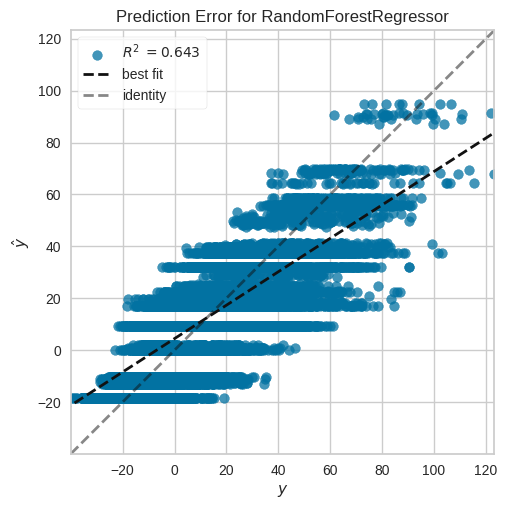

In [126]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(model, X_train, y_train, X_test, y_test);

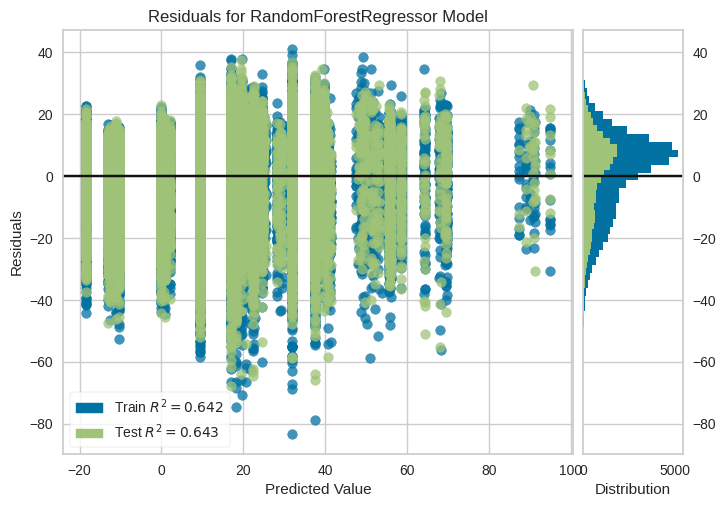

In [129]:
from yellowbrick.regressor import residuals_plot

visualizer = residuals_plot(model,X_train,y_train,X_test,y_test)

In [135]:
from sklearn.model_selection import KFold, cross_validate

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = KFold(n_splits=5, shuffle=True, random_state=520)

cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)

for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    mean_score = "{:.3f}".format(scores.mean())
    std_score = "{:.3f}".format(scores.std())

    print(f"{metric.upper()} Scores: {[f'{val:.3f}' for val in scores]}")
    print(f"{metric.upper()} Media: {mean_score}, Std: {std_score}")
    print('----------------------------------------------------------------')

MAE Scores: ['-11.192', '-10.956', '-11.107', '-11.154', '-11.112']
MAE Media: -11.104, Std: 0.080
----------------------------------------------------------------
RMSE Scores: ['-13.953', '-13.610', '-13.825', '-13.947', '-13.864']
RMSE Media: -13.840, Std: 0.125
----------------------------------------------------------------
R2 Scores: ['0.637', '0.648', '0.639', '0.640', '0.639']
R2 Media: 0.641, Std: 0.004
----------------------------------------------------------------
